<a href="https://colab.research.google.com/github/markienoodle/machine-learning/blob/main/INDX_Model_Evaluation_Assessment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model selection
## Dark matter
We'll use the MAGIC telescope dataset (http://www.openml.org/d/1120). The task is to classifying gamma rays, which consist of high-energy particles. When they hit our atmosphere, they produce chain reactions of other particles called 'showers'. However, similar showers are also produced by other particles (hadrons). We want to be able to detect which ones originate from gamma rays and which ones come from background radiation. To do this, the observed shower patterns are observed and converted into 10 numeric features. You need to detect whether these are gamma rays or background radiation. This is a key aspect of research into dark matter, which is believed to generate such gamma rays. If we can detect where they occur, we can build a map of the origins of gamma radiation, and locate where dark matter may occur in the observed universe. However, we'll first need to accurately detect these gamma rays first.

A quick visualization of the features is shown below. Note that this is not a time series, we just plot the instances in the order they occur in the dataset. The first 12500 or so are examples of signal (gamma), the final 6700 or so are background (hadrons).

In [5]:
# Auto-setup when running on Google Colab
if 'google.colab' in str(get_ipython()):
    !pip install openml

# General imports
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml as oml
from matplotlib import cm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 35.8 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=08d394c9de3bdc6d645f4391f26f3e63f9b0f736ae9dd20d52ba1f218dd350aa
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


In [6]:
# Download MAGIC Telescope data from OpenML. You can repeat this analysis with any other OpenML classification dataset.
magic = oml.datasets.get_dataset(1120)
X, y, _, _ = magic.get_data(target=magic.default_target_attribute, dataset_format='array');
attribute_names = [f.name for i,f in magic.features.items()][:-1][1:]

/tmp/ipykernel_258/2400162915.py:3: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = magic.get_data(target=magic.default_target_attribute, dataset_format='array');


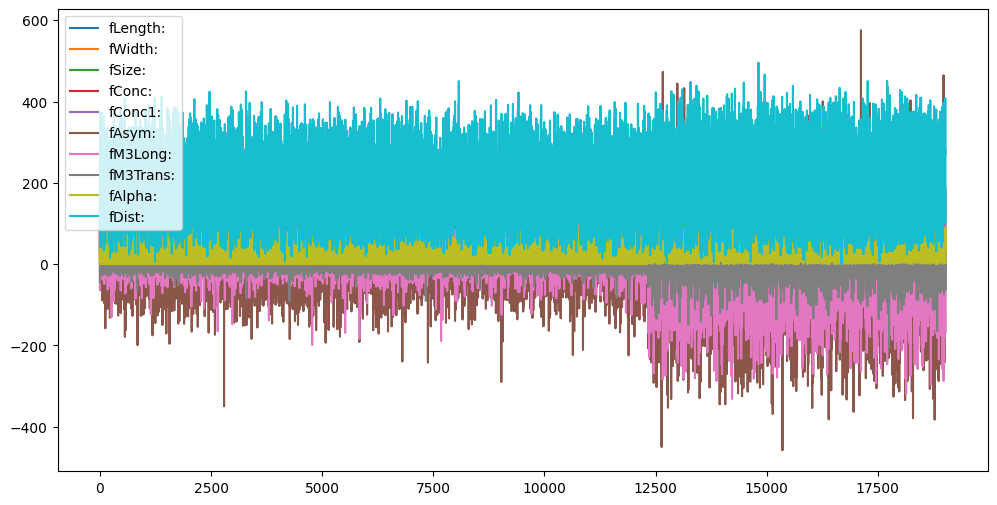

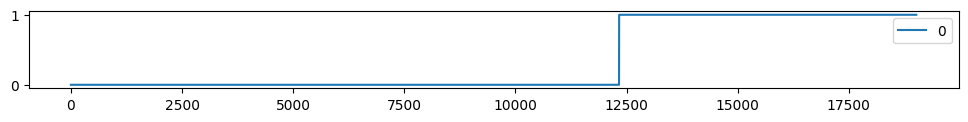

In [7]:
# Quick visualization of the features (top) and the target (bottom)
magic_df = pd.DataFrame(X, columns=attribute_names)
magic_df.plot(figsize=(12,6))
# Also plot the target: 1 = background, 0 = gamma
pd.DataFrame(y).plot(figsize=(12,1));

## Exercise 1: Metrics
Train and evaluate an SVM with RBF kernel (default hyperparameters) using a standard 25% holdout. Report the accuracy, precision, recall, F1 score, and area under the ROC curve (AUC).

Answer the following questions:
* How many of the detected gamma rays are actually real gamma rays?
* How many of all the gamma rays are we detecting?
* How many false positives and false negatives occur?

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1:        {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"AUC:       {roc_auc_score(y_test, svm.decision_function(X_test)):.4f}")

Accuracy:  0.8273
Precision: 0.8820
Recall:    0.5889
F1:        0.7063
AUC:       0.8705


In [9]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Unpack the matrix into individual variables
# This assumes a binary classification with labels 0 and 1
tn, fp, fn, tp = cm.ravel()

print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"---")
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")

False Positives (FP): 132
False Negatives (FN): 689
---
True Positives (TP): 987
True Negatives (TN): 2947


* **How many of the detected gamma rays are actually real gamma rays?**
This is answered by the above cell, in 'Precision' that measures 0.882. This means that the model correctly detects the gamma ray 88.2% of the time.

* **How many of all the gamma rays are we detecting?** This is similarly answered in the above cell, in 'Recall' that measures 0.5589. This means that the model correctly catches about 58.9% of the real gamma rays present in the dataset. This means that it misses a significant portion, the false negatives group.

* **How many false positives and false negatives occur?**
The false positives count are 132 while the false negatives are 689.


## Exercise 2: Preprocessing
SVMs require scaling to perform well. For now, use the following code to scale the data (we'll get back to this in the lab about preprocessing and pipelines). Repeat question 2 on the scaled data. Have the results improved?

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train)
Xs_test  = scaler.transform(X_test)

svm_scaled = SVC(kernel='rbf')
svm_scaled.fit(Xs_train, y_train)
y_pred_s = svm_scaled.predict(Xs_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_s):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_s, pos_label=1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_s, pos_label=1):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_s, pos_label=1):.4f}")
print(f"AUC:       {roc_auc_score(y_test, svm_scaled.decision_function(Xs_test)):.4f}")

Accuracy:  0.8702
Precision: 0.9027
Recall:    0.7082
F1:        0.7937
AUC:       0.9133


* **How many of all the gamma rays are we detecting?** Now that we have scaled our data, recall now measures 0.7082 from 0.5589 before. This is a great improvement.



## Exercise 3: Hyperparameter optimization
Use 50 iterations of random search to tune the $C$ and $gamma$ hyperparameters on the scaled training data. Vary both on a log scale (e.g. from 2^-12 to 2^12). Optimize on AUC and use 3 cross-validation (CV) folds for the inner CV to estimate performance. For the outer loop, just use the train-test split you used before (hence, no nested CV). Report the best hyperparameters and the corresponding AUC score. Is it better than the default? Finally, use them to evaluate the model on the held-out test set, for all 5 metrics we used before.

Extra challenge: plot the samples used by the random search ($C$ vs $gamma$)

Note: The reason we don't use a nested CV just yet is because we would need to rebuild the scaled training and test set multiple times. This is tedious, unless we use pipelines, which we'll cover in a future lab.

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {'C': loguniform(2**-12, 2**12), 'gamma': loguniform(2**-12, 2**12)}

rs = RandomizedSearchCV(SVC(kernel='rbf'), param_dist, n_iter=50, scoring='roc_auc',
                        cv=3, random_state=0, n_jobs=-1)
rs.fit(Xs_train, y_train)

print(f"Best C:     {rs.best_params_['C']:.4f}")
print(f"Best gamma: {rs.best_params_['gamma']:.4f}")
print(f"Best CV AUC: {rs.best_score_:.4f}")

best_svm = rs.best_estimator_
y_pred_best = best_svm.predict(Xs_test)
print()
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best, pos_label=1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best, pos_label=1):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_best, pos_label=1):.4f}")
print(f"AUC:       {roc_auc_score(y_test, best_svm.decision_function(Xs_test)):.4f}")

Best C:     1.4383
Best gamma: 0.2418
Best CV AUC: 0.9178

Accuracy:  0.8719
Precision: 0.8996
Recall:    0.7166
F1:        0.7977
AUC:       0.9175


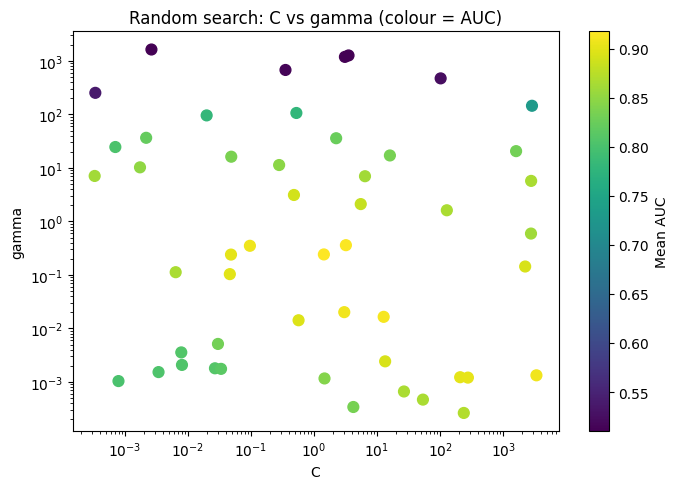

In [12]:
# Extra: scatter plot of sampled C vs gamma
results = rs.cv_results_
plt.figure(figsize=(7, 5))
sc = plt.scatter(results['param_C'], results['param_gamma'],
                 c=results['mean_test_score'], cmap='viridis', s=60)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('C'); plt.ylabel('gamma')
plt.title('Random search: C vs gamma (colour = AUC)')
plt.colorbar(sc, label='Mean AUC')
plt.tight_layout(); plt.show()

- **Report the best hyperparameters and the corresponding AUC score. Is it better than the default?** In this exercise, we have used the following:
  - Best C:     1.4383
  - Best gamma: 0.2418
  - Best CV AUC: 0.9178
  - Test AUC: 0.9175

  This is significantly better than the previous tests of 0.8705 on unscaled and 0.9133 on scaled. There is a signifiacnt increase on AUC and considering the training and test AUC does not much differ, it validates the correctness of the model.


- **Finally, use them to evaluate the model on the held-out test set, for all 5 metrics we used before.**

  **With hyperparameter tuning:**
  - Accuracy:  0.8719
  - Precision: 0.8996
  - Recall:    0.7166
  - F1:        0.7977
  - AUC:       0.9175

  **Default with scaled data:**
  - Accuracy:  0.8702
  - Precision: 0.9027
  - Recall:    0.7082
  - F1:        0.7937
  - AUC:       0.9133
  With this, we can see that our model has significantly improved on all areas except the precision. This proves that hyperparameter tuning actually does improve our model.

## Exercise 4: Threshold calibration
First, plot the Precision-Recall curve for the SVM using the default parameters on the scaled data. Then, calibrate the threshold to find a solution that yields better recall without sacrificing too much precision.

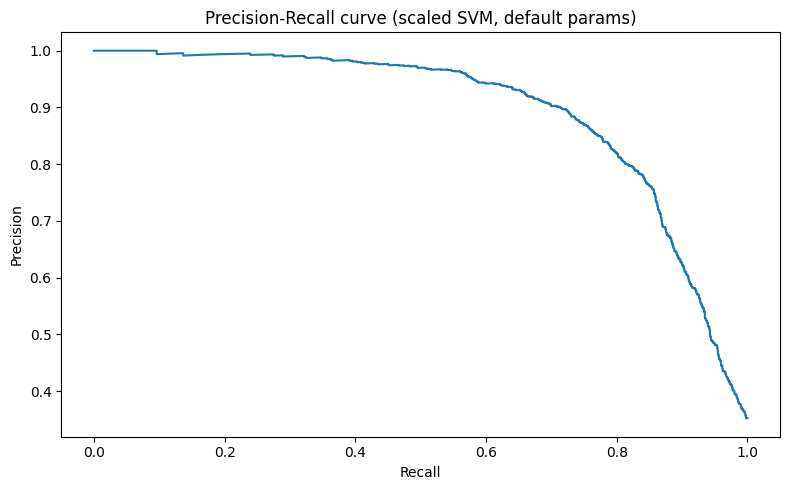

Chosen threshold: -0.4942
Precision: 0.8000
Recall:    0.8162


In [13]:
from sklearn.metrics import precision_recall_curve

scores_s = svm_scaled.decision_function(Xs_test)
precisions, recalls, thresholds = precision_recall_curve(y_test, scores_s)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall curve (scaled SVM, default params)')
plt.tight_layout(); plt.show()

# Choose a threshold that boosts recall while keeping precision >= 0.80
min_precision = 0.80
mask = precisions[:-1] >= min_precision
best_threshold = thresholds[mask][np.argmax(recalls[:-1][mask])]

y_pred_thresh = (scores_s >= best_threshold).astype(int)

print(f"Chosen threshold: {best_threshold:.4f}")
print(f"Precision: {precision_score(y_test, y_pred_thresh):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_thresh):.4f}")

## Exercise 5: Cost function
Assume that a false negative is twice as bad (costly) than a false positive. I.e. we would rather waste time checking gamma ray sources that are not real, than missing an interesting gamma ray source. Use ROC analysis to find the optimal threshold under this assumption.

Finally, let the model make predictions using the optimal threshold and report all 5 scores. Is recall better now? Did we lose a lot of precision?

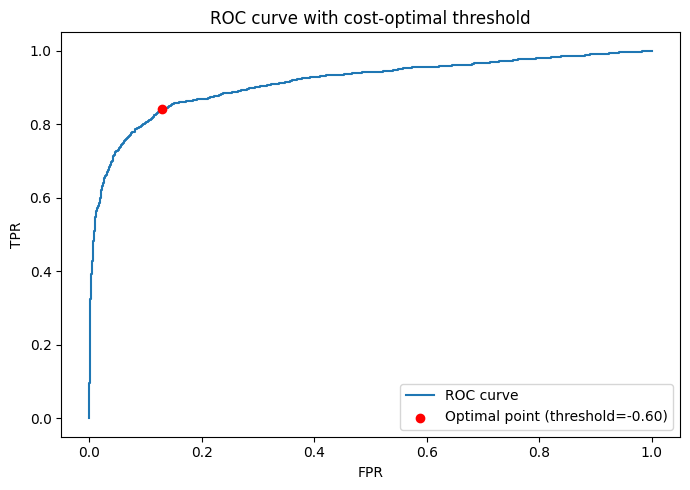

Optimal threshold: -0.5967
Accuracy:  0.8606
Precision: 0.7806
Recall:    0.8407
F1:        0.8095
AUC:       0.9133


In [14]:
from sklearn.metrics import roc_curve

# Cost ratio: FN is twice as costly as FP  ->  cost_FN / cost_FP = 2
# Optimal point on ROC: slope = (cost_FP / cost_FN) * (neg_rate / pos_rate)
cost_FN, cost_FP = 2, 1
pos_rate = (y_test == 1).mean()
neg_rate = 1 - pos_rate
slope = (cost_FP / cost_FN) * (neg_rate / pos_rate)

fprs, tprs, thresholds_roc = roc_curve(y_test, scores_s)

# Point that maximises TPR - slope * FPR
optimal_idx = np.argmax(tprs - slope * fprs)
optimal_threshold = thresholds_roc[optimal_idx]

plt.figure(figsize=(7, 5))
plt.plot(fprs, tprs, label='ROC curve')
plt.scatter(fprs[optimal_idx], tprs[optimal_idx], color='red', zorder=5,
            label=f'Optimal point (threshold={optimal_threshold:.2f})')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC curve with cost-optimal threshold')
plt.legend(); plt.tight_layout(); plt.show()

y_pred_cost = (scores_s >= optimal_threshold).astype(int)

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_cost):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cost):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cost):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_cost):.4f}")
print(f"AUC:       {roc_auc_score(y_test, scores_s):.4f}")

- **Finally, let the model make predictions using the optimal threshold and report all 5 scores. Is recall better now? Did we lose a lot of precision?**
Using the new cost-optimal threshold of -0.5967, your model achieved the following scores:

    - Accuracy: 0.8606
    - Precision: 0.7806
    - Recall: 0.8407
    - F1 Score: 0.8095
    - AUC: 0.9133

  **Precision-recall curve:**
  - Precision: 0.8000
  - Recall:    0.8162

  **ROC curve with cost-optimal threshold:**
  - Precision: 0.7806
  - Recall:    0.8407
  
  As we can see, recall *is* significantly better. But this came at the cost of a lower precision. But, the increaase in recall beats the decrease in precision as this is meticulously calculated and this is the best offer we can have.
  